 Part 3: NLP and Sequence Modeling Mini Project

Task 1: Dataset Understanding

In [1]:
!pip install nltk scikit-learn tensorflow pandas matplotlib seaborn

In [2]:
!pip install nltk scikit-learn tensorflow pandas matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
!unzip /content/part_3_nlp_sequence_modeling-20260516T043106Z-3-001.zip

Archive:  /content/part_3_nlp_sequence_modeling-20260516T043106Z-3-001.zip
  inflating: part_3_nlp_sequence_modeling/data_dictionary.md  
  inflating: part_3_nlp_sequence_modeling/customer_support_text_classification.csv  


In [7]:
df = pd.read_csv("/content/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [8]:
print("Number of Records:", len(df))

print("\nColumns:")
print(df.columns)

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

print("\nSample Messages:")
print(df['customer_message'].head())

df['text_length'] = df['customer_message'].apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())

Number of Records: 1500

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Messages:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Average Text Length:
72.75666666666666


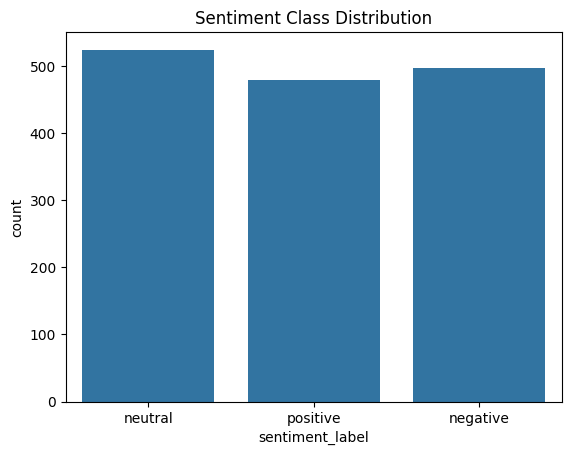

In [9]:
sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Class Distribution")

plt.show()

In [12]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
df['clean_text'] = df['customer_message'].apply(clean_text)

Task 2: Text Preprocessing

In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


Task 3: Text Vectorization

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text']).toarray()

print(X.shape)

(1500, 146)


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment_label'])

print(y[:10])

[1 1 2 0 1 1 2 1 1 0]


Text must be converted into numerical vectors because machine learning and deep learning models cannot directly understand raw text data. Vectorization methods such as TF-IDF transform textual information into numerical form so models can process patterns mathematically.

 Task 4: Baseline Model

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



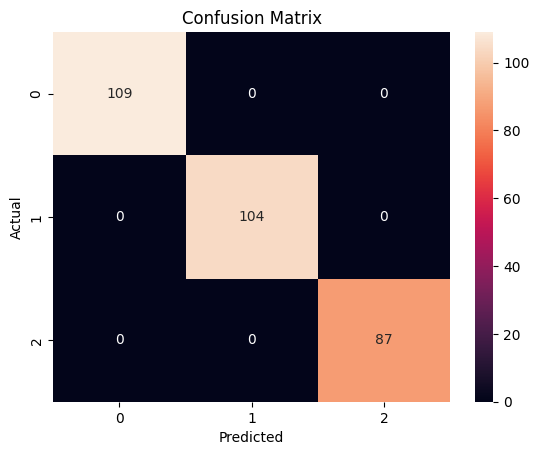

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Task 5: Sequence Model using LSTM

In [23]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

padded_sequences = pad_sequences(
    sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)

print(padded_sequences.shape)

(1500, 100)


In [24]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000, output_dim=64, input_length=100)
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000, output_dim=64, input_length=100)
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
loss, acc = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2900 - loss: 1.1010
LSTM Accuracy: 0.28999999165534973


Task 6: Attention and Transformer Reflection

Why RNNs struggle with long-term dependencies
RNNs process sequences one word at a time, but information from earlier words gradually fades as sequences become longer. This leads to the vanishing gradient problem.

How LSTMs help with memory
LSTMs use memory cells and gating mechanisms to preserve important information for longer durations and forget irrelevant information.

What attention solves
Attention mechanisms help models focus on important words in the input sequence rather than depending only on the final hidden state.

Why transformers are important
Transformers use self-attention and parallel processing, making them highly efficient for modern NLP applications such as GPT and BERT.

In [28]:
from google.colab import files

files.download("model_evaluation.csv")

FileNotFoundError: Cannot find file: model_evaluation.csv

In [29]:
sample_df = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})

sample_df.to_csv("sample_predictions.txt", index=False)

print("sample_predictions.txt created")

sample_predictions.txt created


In [30]:
results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy]
})

results.to_csv("model_evaluation.csv", index=False)

print("model_evaluation.csv created")

model_evaluation.csv created


In [31]:
from google.colab import files

files.download("model_evaluation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files

files.download("model_evaluation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

files.download("sample_predictions.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>